In [ ]:
import os
import sqlite3
import numpy as np
import pandas as pd
import vectorbt as vbt
import quantstats as qs
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

# 导入外部因子与过滤器模块（与主回测逻辑解耦）
import factors
import filters

warnings.filterwarnings("ignore")
# 设置绘图中文与负号显示（用于可视化输出）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


class VectorbtRotationStrategy:
    """VectorBT 为基础的 ETF 因子轮动回测框架。

    功能简介：支持多标的横向轮动、可插拔因子与过滤器、真实手续费
    与资金共享（cash sharing）等特性。
    """
    def __init__(self, db_path, code_dict, safe_asset_code=None, benchmark_code='510300', start_date='20150101', end_date='20260101'):
        self.db_path = db_path
        self.code_dict = code_dict
        self.code_list = list(code_dict.keys())
        self.safe_asset_code = safe_asset_code
        self.benchmark_code = benchmark_code
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        
        # 原始行情数据（宽表格式）
        self.prices = None
        self.highs = None
        self.lows = None
        
        # 初始化加载数据
        self._load_data()

    def _load_data(self):
        """从本地 SQLite 数据库读取日线数据并构建宽表（Wide DataFrame）。

        行为要点：按日期筛选、以日期为索引，分别提取收盘/最高/最低并
        横向合并为宽表，使用前向填充对齐缺失值。
        """
        print("📥 正在从本地数据库加载数据...")
        conn = sqlite3.connect(self.db_path)
        df_close_list, df_high_list, df_low_list = [], [], []

        # 需要加载的全部标的：风险资产池 + 可选的避险资产
        all_codes = self.code_list.copy()
        if self.safe_asset_code and self.safe_asset_code not in all_codes:
            all_codes.append(self.safe_asset_code)

        for code in all_codes:
            try:
                query = f'SELECT 日期, 最高, 最低, 收盘 FROM "{code}"'
                df = pd.read_sql(query, conn)
                df['日期'] = pd.to_datetime(df['日期'])
                df = df[(df['日期'] >= self.start_date) & (df['日期'] <= self.end_date)]
                df = df.set_index('日期')

                # 分别收集各列并重命名为标的代码，便于后续合并
                df_close_list.append(df[['收盘']].rename(columns={'收盘': code}))
                df_high_list.append(df[['最高']].rename(columns={'最高': code}))
                df_low_list.append(df[['最低']].rename(columns={'最低': code}))

            except Exception as e:
                print(f"⚠️ 读取 {code} 失败: {e}")

        conn.close()

        # 横向合并为宽表，按日期排序并使用前向填充（ffill）对齐数据
        self.prices = pd.concat(df_close_list, axis=1).sort_index().ffill()
        self.highs = pd.concat(df_high_list, axis=1).sort_index().ffill()
        self.lows = pd.concat(df_low_list, axis=1).sort_index().ffill()
        print(f"✅ 数据加载完成，形状: {self.prices.shape}")
   
    def generate_target_weights(self, factor_df, top_n=1, pre_filter_mask=None, post_filter_mask=None):
        """基于因子得分生成每日目标仓位（目标权重矩阵）。

        参数说明：
        - factor_df: 每日因子得分的宽表（列为风险资产代码）。
        - top_n: 每日选取得分前 N 的标的作为仓位目标。
        - pre_filter_mask: 前置布尔掩码（True 表示可参与排名），在排名前剔除不合格标的。
        - post_filter_mask: 后置布尔掩码，在选出 Top N 后再进行复核，未通过者的权重会在幸存者间重分。
        """
        print(f"🎯 正在根据因子生成目标权重 (Top {top_n})...")

        # 前置过滤：将不合格位置置为 NaN，使其不参与横向排名
        if pre_filter_mask is not None:
            print("🧩 已接入前置过滤器：在排名前剔除不合格标的。")
            factor_df = factor_df.where(pre_filter_mask, np.nan)

        risk_assets = list(factor_df.columns)

        # 横向排名（相对动量）：得分越高排名越靠前
        ranks = factor_df.rank(axis=1, ascending=False)
        mask_top = ranks <= top_n

        # 后置过滤与权重重分配
        if post_filter_mask is not None:
            print("🧩 已接入后置过滤器：对 Top N 进行最终复核并重分权重。")
            mask_top = mask_top & post_filter_mask
            valid_count = mask_top.sum(axis=1)
            # 幸存者平分全部风险敞口；若无幸存者则留为 NaN，随后填 0
            risk_weights = mask_top.astype(float).div(valid_count.replace(0, np.nan), axis=0)
        else:
            # 无后置过滤：直接等权分配给 Top N
            risk_weights = pd.DataFrame(0.0, index=factor_df.index, columns=risk_assets)
            risk_weights[mask_top] = 1.0 / top_n

        final_risk_weights = risk_weights.fillna(0.0)

        # 计算未分配到风险资产的剩余权重（用于避险资产或现金）
        remaining_weights = (1.0 - final_risk_weights.sum(axis=1)).round(4)

        # 构建最终输出：与 self.prices 列一致的目标权重宽表
        target_weights = pd.DataFrame(0.0, index=factor_df.index, columns=self.prices.columns)
        target_weights[risk_assets] = final_risk_weights

        # 将剩余权重分配到指定的避险资产（若有且数据存在）
        if self.safe_asset_code and self.safe_asset_code in self.prices.columns:
            target_weights[self.safe_asset_code] = remaining_weights
        elif self.safe_asset_code:
            print(f"⚠️ 警告: 指定避险资产 '{self.safe_asset_code}' 未加载到行情，退化为持有现金（空仓）。")

        return target_weights
    def run_backtest(self, target_weights, init_cash=100000, fees=0.0001):
        """执行回测并返回 vectorbt 的 Portfolio 对象。

        参数说明：`target_weights` 应为目标仓位（target percent），
        回测以日频执行，支持 `cash_sharing` 和真实手续费设置。
        """
        print(f"🚀 开始撮合回测 (初始资金: {init_cash}, 手续费: {fees})...")

        # 注意：若需要 T-1 信号执行，可将 target_weights.shift(1) 传入
        pf = vbt.Portfolio.from_orders(
            close=self.prices,
            size=target_weights,
            size_type='targetpercent',
            group_by=True,
            cash_sharing=True,
            init_cash=init_cash,
            fees=fees,
            slippage=0.000,
            freq='D'
        )
        print("✅ 回测完成！")
        return pf


📥 正在从本地数据库加载数据...
✅ 数据加载完成，形状: (2430, 7)
🧮 计算因子: 250日纯动量...
🛡️ 计算过滤器: 近期下跌过滤 (最大允许跌幅: 5.0%)
🎯 正在根据因子生成目标权重 (Top 1)...
🧩 已接入外部过滤器插件，正在剔除高风险标的...
🔓 绝对动量已关闭，仅使用相对排名分配权重
🚀 开始撮合回测 (初始资金: 100000, 费率: 6e-05)...
✅ 回测完成！

📝 正在生成 QuantStats HTML 报告...


                    Benchmark    Strategy
------------------  -----------  ----------
Start Period        2016-01-05   2016-01-05
End Period          2025-12-31   2025-12-31
Risk-Free Rate      0.0%         0.0%
Time in Market      98.0%        94.0%

Cumulative Return   506.37%      365.07%
CAGR﹪              13.26%       11.2%

Sharpe              0.95         0.84
Prob. Sharpe Ratio  99.82%       99.44%
Sortino             1.36         1.18
Sortino/√2          0.96         0.83
Omega               1.17         1.17

Max Drawdown        -28.57%      -28.87%
Longest DD Days     569          727

Gain/Pain Ratio     0.19         0.17
Gain/Pain (1M)      1.21         1.03

Payoff Ratio        0.93         1.01
Profit Factor       1.19         1.17
Common Sense Ratio  1.3          1.3
CPC Index           0.6          0.62
Tail Ratio          1.09         1.11
Outlier Win Ratio   3.86         4.18
Outlier Loss Ratio  4.05         4.22

MTD                 -2.01%       -0.0%
3M            

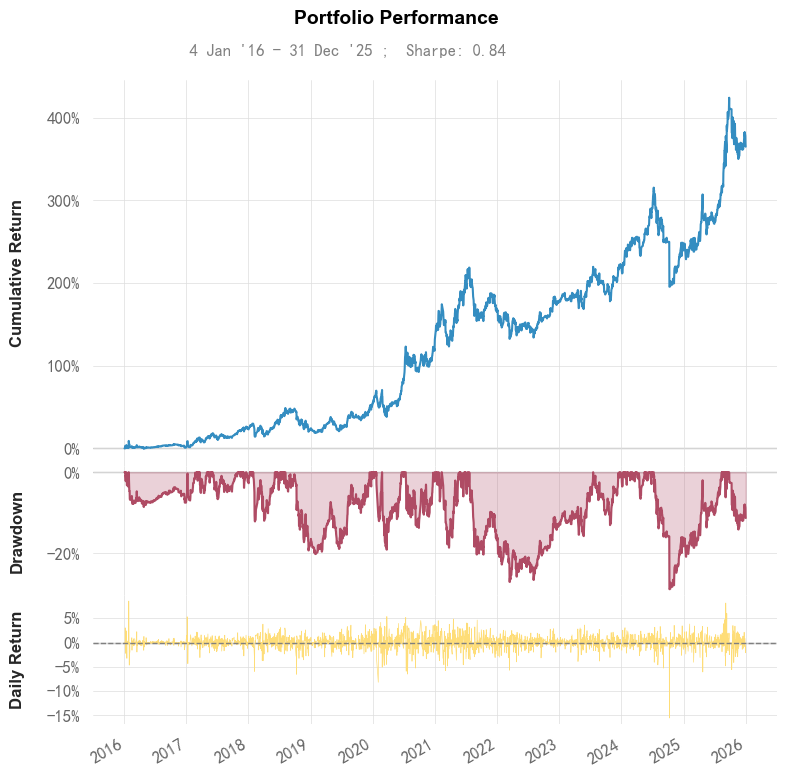

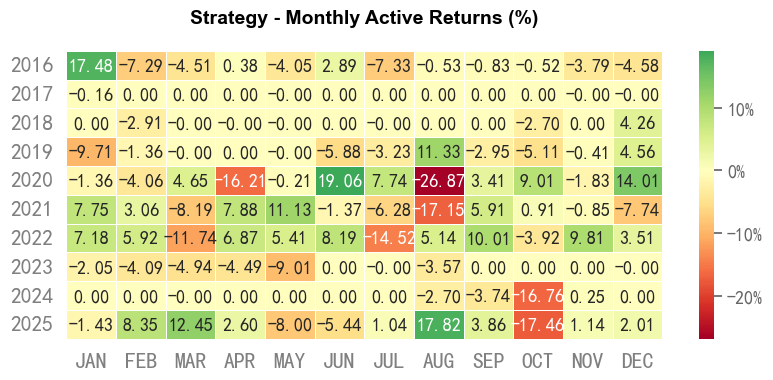

In [ ]:

# ================= 运行入口与分析 =================
if __name__ == "__main__":
    
    # 数据库路径（相对 __file__ 的位置）
    DB_PATH = 'JaimeQuant/database/dayK.db'

    # 风险资产字典：仅包含用于因子横向排名的标的（不含避险资产）
    ETF_DICT = {
        # '510300': '沪深300ETF华泰柏瑞',
        # '510500': '中证500ETF',
        # '510880': '红利ETF华泰柏瑞',
        # '159915': '创业板ETF易方达',
        '513100': '纳指ETF',
        '518880': '黄金ETF华安',
        '588000': '科创50ETF',
        '159949': '创业板50ETF华安',
        '563300': '中证2000ETF华泰柏瑞',
        '512890': '红利低波ETF华泰柏瑞',
        # '159985': '豆粕ETF',
    }
    BENCHMARK_CODE = '513100'

    # 避险资产单独定义，不放入 ETF_DICT；可设为 None 表示不配置避险仓
    SAFE_ASSET_CODE = '161119'
    REPORT_TITLE = "ETF Rotation 10Y"
    
    # 2. 实例化策略框架（构建并加载行情数据）
    strategy = VectorbtRotationStrategy(
        db_path=DB_PATH,
        code_dict=ETF_DICT,
        safe_asset_code=SAFE_ASSET_CODE, # 👈 在初始化框架时，以专用通道传入避险资产
        benchmark_code=BENCHMARK_CODE,
        # start_date='20160101',  # 10年数据，覆盖多个牛熊周期
        # end_date='20260101',
        # start_date='20190101',  # 5年数据，覆盖最近的牛熊周期
        # end_date='20260101',
        start_date='20230301',  # 3年数据，部分ETF上市较晚
        end_date='20260301',
    )

    # 获取风险资产的价格/最高/最低（用于因子与过滤器计算）
    risk_prices = strategy.prices[strategy.code_list]
    risk_highs = strategy.highs[strategy.code_list]
    risk_lows = strategy.lows[strategy.code_list]
    
    # 因子选择
    factor = factors.calc_pure_momentum(risk_prices, window=20)  # 纯动量因子
    # factor = factors.calc_atr_dynamic_score(risk_prices, risk_highs, risk_lows)  # ATR 动态窗口得分因子
    # factor = factors.calc_trend_score(risk_prices, window=20)  # 线性回归趋势得分因子

    # 过滤器选择
    # rsrs_safe_mask = filters.filter_rsrs_timing(risk_highs, risk_lows, window=16, z_window=300, threshold=-0.7)
    drop_safe_mask = filters.filter_recent_drop(risk_prices, 0.05)
    # abs_mom_120_mask = filters.filter_absolute_momentum(risk_prices, window=120, threshold=0.0)
    # combined_mask = rsrs_safe_mask & drop_safe_mask

    # 3. 根据因子与过滤器生成每日目标权重
    weights_atr = strategy.generate_target_weights(
        factor,
        top_n=1,
        pre_filter_mask=drop_safe_mask,
        # post_filter_mask=abs_mom_120_mask # 绝对动量可作为后处理，选出来如果动量不足再没收重分        
    )

    # 运行回测并获取 Portfolio 结果
    pf_atr = strategy.run_backtest(weights_atr, init_cash=100000, fees=0.00006)

    # # 4. 打印回测基本统计
    # print("\n" + "=" * 40)
    # print("📈 回测基础统计指标")
    # print("=" * 40)
    # print(pf_atr.stats())

    # 5. 使用 QuantStats 生成 HTML 报告
    print("\n📝 正在生成 QuantStats HTML 报告...")
    strategy_returns = pf_atr.returns()
    benchmark_returns = strategy.prices[BENCHMARK_CODE].pct_change().fillna(0)
    strategy_returns, benchmark_returns = strategy_returns.align(benchmark_returns, join='inner')
    qs.reports.metrics(strategy_returns, benchmark=benchmark_returns, mode='basic')

    # report_name = f"{REPORT_TITLE}_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
    # script_dir = os.path.dirname(os.path.abspath(__file__))
    # report_path = os.path.join(script_dir, 'test_reports', report_name)
    # qs.reports.html(
    #     returns=strategy_returns,
    #     benchmark=benchmark_returns,
    #     title=REPORT_TITLE,
    #     output=report_path,
    # )
    # print(f"✅ 报告已生成并保存至: {report_path}")

    # 若需要交互式展示，可取消下一行注释
    # pf_atr.plot().show()
